# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

A plain linear model can predict any real number. That is fine when the outcome itself is continuous, but it causes problems when the outcome is binary or categorical. A dropout probability, for example, should stay between 0 and 1. Logistic regression handles that by first building a linear score and then passing it through an activation function, usually the logistic function. The latent linear score keeps the model simple, while the activation function turns that score into a valid probability.

The main advantage over an ordinary linear model is that the fitted values match the kind of target we actually have. For classification problems, that means valid probabilities and a decision rule tied to those probabilities.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross-entropy measures how far the predicted probabilities are from the observed outcomes. It rewards the model when it gives high probability to the class that actually occurred, and it penalizes the model heavily when it is confidently wrong. That makes it a good fit for logistic regression, because logistic regression is trying to estimate class probabilities rather than just match labels in a rough way.

For binary outcomes we use binary cross-entropy. For more than two classes we use categorical cross-entropy. In both cases, the loss lines up with maximum likelihood estimation for the model.

3. True or false, and explain: Logistic regression is a linear model.

This is true it is treated as a linear model. The log-odds are linear in the predictors:

$$
\log\left(\frac{p}{1-p}\right)=b_0+b_1x_1+\cdots+b_kx_k.
$$

So the latent score is linear. The predicted probability is not linear in the predictors because the logistic function bends the line into an S-shape.

4. True or false, and explain: Logistic regression cannot be used for classification.

This is false. Logistic regression is one of the standard classification methods. It outputs probabilities, and those probabilities can be turned into class labels with a threshold such as 0.5.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Not directly. In an ordinary linear model, a coefficient gives the change in the prediction for a one-unit change in the feature. In logistic regression, a coefficient gives the change in the log-odds for a one-unit change in the feature, holding the other variables fixed. The effect on the predicted probability depends on where you already are on the logistic curve, so it is not constant.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

This is false. Logistic regression is nonlinear in the predicted probability, but it is still linear in the latent score. That means it does not automatically discover interactions, curved trends, or transformed relationships. If those matter, we still need feature engineering such as interaction terms, splines, or polynomial terms.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

This is false. Logistic regression is better when the response is binary or categorical. Ordinary least squares is better when the response is continuous and the linear-model assumptions make sense. Neither model replaces the other in every setting. The right choice depends on the target variable and the question being asked.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [2]:

student = pd.read_csv("data.csv", sep=";")

student_cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]

student = student[student_cols].copy()
student.isna().sum()


Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

In [3]:

student["dropout"] = (student["Target"] == "Dropout").astype(int)
student.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

In [4]:

X_drop = student[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y_drop = student["dropout"]

log_drop = LogisticRegression(max_iter=5000)
log_drop.fit(X_drop, y_drop)

drop_coef = pd.Series(log_drop.coef_[0], index=X_drop.columns)
drop_coef


Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64

The coefficient signs are the main thing to read here.

- `Debtor` is positive, so students with debt are predicted to have a higher dropout probability.
- `Age at enrollment` is also positive, so older students in this sample tend to have a higher dropout probability.
- `Tuition fees up to date` is strongly negative, so being current on tuition is associated with a much lower dropout probability.
- `Scholarship holder` is negative, so scholarship holders are less likely to drop out.

The tuition variable has the largest effect by magnitude in this model, so yes, being up to date on tuition looks like it reduces dropout risk quite a lot.


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

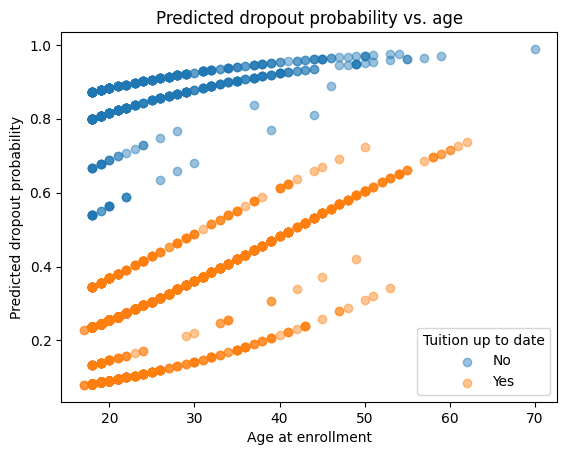

In [5]:

student["dropout_prob_logistic"] = log_drop.predict_proba(X_drop)[:, 1]

plot_student = student.copy()
plot_student["Tuition fees up to date"] = plot_student["Tuition fees up to date"].map({0: "No", 1: "Yes"})

for tuition_status, group in plot_student.groupby("Tuition fees up to date"):
    plt.scatter(
        group["Age at enrollment"],
        group["dropout_prob_logistic"],
        alpha=0.45,
        label=tuition_status,
    )

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs. age")
plt.legend(title="Tuition up to date")
plt.show()


In [6]:

X_all_paid = X_drop.copy()
X_all_paid["Tuition fees up to date"] = 1

X_all_unpaid = X_drop.copy()
X_all_unpaid["Tuition fees up to date"] = 0

tuition_effect = (
    log_drop.predict_proba(X_all_paid)[:, 1]
    - log_drop.predict_proba(X_all_unpaid)[:, 1]
)

pd.Series({
    "Average change in predicted dropout probability when tuition is up to date": tuition_effect.mean(),
    "Most negative age-group average effect": pd.DataFrame({"Age": student["Age at enrollment"], "Effect": tuition_effect}).groupby("Age")["Effect"].mean().min(),
    "Least negative age-group average effect": pd.DataFrame({"Age": student["Age at enrollment"], "Effect": tuition_effect}).groupby("Age")["Effect"].mean().max(),
})


Average change in predicted dropout probability when tuition is up to date   -0.516182
Most negative age-group average effect                                       -0.537499
Least negative age-group average effect                                      -0.113191
dtype: float64

Across the sample, switching a student from not-current to current on tuition lowers the predicted dropout probability by about 0.516, or 51.6 percentage points on average.

The drop is largest for the younger part of the sample, especially the early 20s. The effect gets smaller at older ages. That makes sense in this model because the positive age coefficient pushes baseline dropout risk upward, and the logistic curve flattens at more extreme probability levels.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [7]:

drop_pred = log_drop.predict(X_drop)
drop_cm = pd.DataFrame(
    confusion_matrix(y_drop, drop_pred),
    index=["Actual not dropout", "Actual dropout"],
    columns=["Predicted not dropout", "Predicted dropout"],
)
drop_acc = accuracy_score(y_drop, drop_pred)

drop_cm, drop_acc


(                    Predicted not dropout  Predicted dropout
 Actual not dropout                   2841                162
 Actual dropout                        891                530,
 0.7619801084990958)

The model classifies about 76.2% of observations correctly. It does much better on the non-dropout group than on the dropout group, which is common when the classes are imbalanced and the default threshold is 0.5.


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

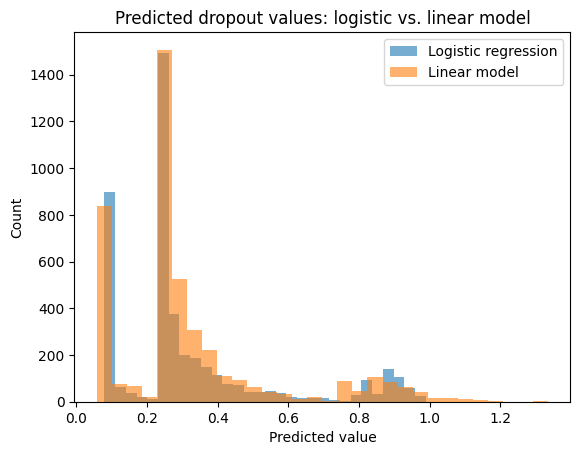

(     dropout_prob_logistic  dropout_prob_linear
 min               0.079471             0.058320
 max               0.989133             1.334954,
 0.7633363471971067)

In [8]:

lin_drop = LinearRegression()
lin_drop.fit(X_drop, y_drop)

student["dropout_prob_linear"] = lin_drop.predict(X_drop)

lin_drop_pred = (student["dropout_prob_linear"] >= 0.5).astype(int)
lin_drop_acc = accuracy_score(y_drop, lin_drop_pred)

plt.hist(student["dropout_prob_logistic"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(student["dropout_prob_linear"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted value")
plt.ylabel("Count")
plt.title("Predicted dropout values: logistic vs. linear model")
plt.legend()
plt.show()

student[["dropout_prob_logistic", "dropout_prob_linear"]].agg(["min", "max"]), lin_drop_acc


The linear model gets a very similar training accuracy here, but the predictions are harder to interpret. Some of its fitted values go above 1, which is not valid for a probability. Logistic regression keeps every predicted value between 0 and 1, so it is the better model for this problem even if the raw accuracy looks similar.


5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The highest-risk students in this model are the ones who combine several warning signs at once: they have debt, they are not up to date on tuition, they are not scholarship holders, and they enrolled at an older age.

Reasonable interventions would focus on the variables that look actionable. Financial support is the clearest one here: payment plans, emergency grants, tuition counseling, and fast outreach when a balance becomes overdue. Scholarship review and academic advising could help too, especially for students who also seem to be under strain in their first semester.


6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [9]:

X_multi = student[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = student["Target"]

multi_target = LogisticRegression(max_iter=5000)
multi_target.fit(X_multi, y_multi)

multi_pred = multi_target.predict(X_multi)
multi_prob = pd.DataFrame(multi_target.predict_proba(X_multi), columns=multi_target.classes_)

multi_cm = pd.crosstab(
    pd.Series(y_multi, name="Actual"),
    pd.Series(multi_pred, name="Predicted"),
)

multi_acc = accuracy_score(y_multi, multi_pred)

multi_cm, multi_acc


(Predicted  Dropout  Graduate
 Actual                      
 Dropout       1054       367
 Enrolled       280       514
 Graduate       146      2063,
 0.7045660036166366)

In [10]:

multi_prob.head()


,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


The hard classification reaches about 70.5% accuracy, but it does not predict every class. In the confusion matrix, the model predicts `Dropout` and `Graduate`, but it never chooses `Enrolled` as the most likely class. That means the middle category is being absorbed by the other two when we force a single label.

The probability output is more informative. The `.predict_proba()` values do assign nonzero probability to all three classes, including `Enrolled`. So the model does represent every class in probability form even though the hard classification skips one of them.


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [11]:

cirrhosis = pd.read_csv("cirrhosis.csv")

cirrhosis_cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
cirrhosis = cirrhosis[cirrhosis_cols].copy()

cirrhosis.isna().sum()


Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

`Bilirubin`, `Edema`, and `Status` are complete. `Drug` has 106 missing values and `Stage` has 6 missing values. For each model below, I dropped rows only when a variable needed for that specific model was missing.

For survival, I coded `C` and `CL` as alive (`1`) and `D` as dead (`0`).


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [12]:

survival = cirrhosis[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()
survival["survived"] = survival["Status"].isin(["C", "CL"]).astype(int)

X_survival = survival[["Edema", "Drug", "Bilirubin"]]
y_survival = survival["survived"]

pre_survival = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["Edema", "Drug"]),
        ("num", "passthrough", ["Bilirubin"]),
    ]
)

log_survival = Pipeline(
    steps=[
        ("pre", pre_survival),
        ("model", LogisticRegression(max_iter=5000)),
    ]
)

log_survival.fit(X_survival, y_survival)

feature_names = list(
    log_survival.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(["Edema", "Drug"])
) + ["Bilirubin"]

survival_coef = pd.Series(log_survival.named_steps["model"].coef_[0], index=feature_names)
survival_coef


Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
Bilirubin      -0.351424
dtype: float64

The baseline categories are `Edema = N` and `Drug = D-penicillamine`, so the signs are interpreted relative to those groups.

- `Bilirubin` is negative, so higher bilirubin predicts a lower survival probability.
- `Edema_S` and `Edema_Y` are both negative, so patients with edema have lower survival probability than patients with no edema. The drop is much larger for `Y`, which matches the fact that persistent edema signals more severe disease.
- `Drug_Placebo` is positive. That means placebo is estimated to have slightly higher survival probability than D-penicillamine in this fitted model. In other words, this model does **not** show the drug improving survival.


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

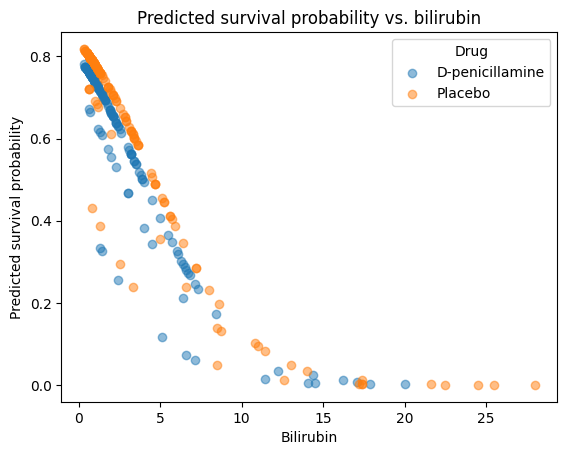

In [13]:

survival["survival_prob_logistic"] = log_survival.predict_proba(X_survival)[:, 1]

plot_survival = survival.copy()

for drug_name, group in plot_survival.groupby("Drug"):
    plt.scatter(
        group["Bilirubin"],
        group["survival_prob_logistic"],
        alpha=0.5,
        label=drug_name,
    )

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs. bilirubin")
plt.legend(title="Drug")
plt.show()


In [14]:

X_all_drug = X_survival.copy()
X_all_drug["Drug"] = "D-penicillamine"

X_all_placebo = X_survival.copy()
X_all_placebo["Drug"] = "Placebo"

drug_effect = (
    log_survival.predict_proba(X_all_drug)[:, 1]
    - log_survival.predict_proba(X_all_placebo)[:, 1]
)

pd.Series({
    "Average change in predicted survival probability from D-penicillamine vs placebo": drug_effect.mean(),
    "Minimum effect": drug_effect.min(),
    "Maximum effect": drug_effect.max(),
})


Average change in predicted survival probability from D-penicillamine vs placebo   -0.042427
Minimum effect                                                                     -0.057741
Maximum effect                                                                     -0.000035
dtype: float64

In this fitted model, D-penicillamine does not increase predicted survival for the observed bilirubin values. The estimated effect is negative across the sample, with an average change of about -0.042 compared with placebo.

The bilirubin effect is much clearer: lower bilirubin is associated with higher survival probability, and survival falls as bilirubin rises.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [15]:

survival_pred = log_survival.predict(X_survival)
survival_cm = pd.DataFrame(
    confusion_matrix(y_survival, survival_pred),
    index=["Actual dead", "Actual alive"],
    columns=["Predicted dead", "Predicted alive"],
)
survival_acc = accuracy_score(y_survival, survival_pred)

survival_cm, survival_acc


(              Predicted dead  Predicted alive
 Actual dead               59               66
 Actual alive              16              171,
 0.7371794871794872)

The survival model classifies about 73.7% of observations correctly. It is better at identifying survivors than non-survivors, which shows up in the confusion matrix.


5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

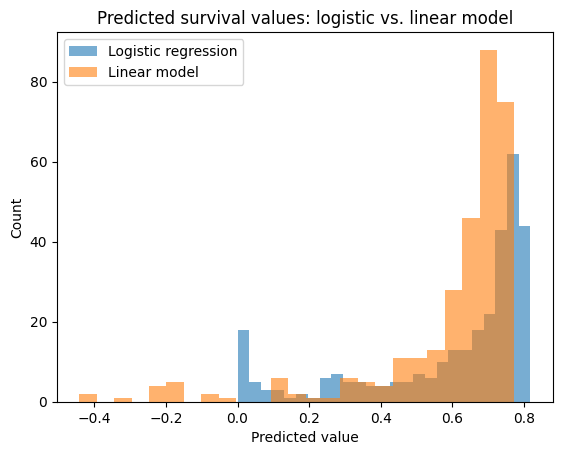

(     survival_prob_logistic  survival_prob_linear
 min                0.000170             -0.441740
 max                0.818412              0.773868,
 0.7211538461538461)

In [16]:

lin_survival = Pipeline(
    steps=[
        ("pre", pre_survival),
        ("model", LinearRegression()),
    ]
)

lin_survival.fit(X_survival, y_survival)
survival["survival_prob_linear"] = lin_survival.predict(X_survival)

lin_survival_pred = (survival["survival_prob_linear"] >= 0.5).astype(int)
lin_survival_acc = accuracy_score(y_survival, lin_survival_pred)

plt.hist(survival["survival_prob_logistic"], bins=25, alpha=0.6, label="Logistic regression")
plt.hist(survival["survival_prob_linear"], bins=25, alpha=0.6, label="Linear model")
plt.xlabel("Predicted value")
plt.ylabel("Count")
plt.title("Predicted survival values: logistic vs. linear model")
plt.legend()
plt.show()

survival[["survival_prob_logistic", "survival_prob_linear"]].agg(["min", "max"]), lin_survival_acc


The linear model again gets a somewhat similar training accuracy, but its fitted values extend below 0, which makes no sense for a probability. Logistic regression stays within the proper range and is easier to interpret as a survival-probability model.


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [17]:

stage_data = cirrhosis[["Edema", "Bilirubin", "Stage"]].dropna().copy()
stage_data["Stage"] = stage_data["Stage"].astype(int).astype(str)

X_stage = stage_data[["Edema", "Bilirubin"]]
y_stage = stage_data["Stage"]

pre_stage = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["Edema"]),
        ("num", "passthrough", ["Bilirubin"]),
    ]
)

stage_model = Pipeline(
    steps=[
        ("pre", pre_stage),
        ("model", LogisticRegression(max_iter=5000)),
    ]
)

stage_model.fit(X_stage, y_stage)

stage_pred = stage_model.predict(X_stage)
stage_prob = pd.DataFrame(stage_model.predict_proba(X_stage), columns=stage_model.named_steps["model"].classes_)

stage_cm = pd.crosstab(
    pd.Series(y_stage, name="Actual"),
    pd.Series(stage_pred, name="Predicted"),
)

stage_acc = accuracy_score(y_stage, stage_pred)

stage_cm, stage_acc


(Predicted    3   4
 Actual            
 1           21   0
 2           76  16
 3          125  26
 4          100  42,
 0.4393203883495146)

In [18]:

stage_prob.head()


,1,2,3,4
0,0.000469,0.051111,0.137333,0.811087
1,0.068674,0.255046,0.397582,0.278697
2,0.039844,0.139561,0.340088,0.480507
3,0.035217,0.137519,0.338843,0.488421
4,0.035048,0.243195,0.404020,0.317737


The hard classification accuracy is about 43.9%, which is not very strong. More important, the model only predicts stages 3 and 4 as hard labels. It never chooses stage 1 or 2 as the top class.

The probability output is again more informative than the hard labels. The `.predict_proba()` table gives nonzero probabilities for all four stages, so the model is spreading probability mass across the full set of classes even though the final class label collapses toward the middle-to-late stages.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**Q4.**

 1. Linear model derivative

For the linear model
$$
\hat{y} = b_0 + \sum_{k=1}^K b_k x_k,
$$
the derivative with respect to the $k$-th feature is
$$
\frac{\partial \hat{y}}{\partial x_k} = b_k.
$$

So for a one-unit increase in $x_k$, the prediction changes by exactly $b_k$. That effect is constant. It does not depend on the current value of $x$.

 2. Logistic model derivative

For the logistic model
$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}},
$$
let
$$
L = b \cdot x.
$$
Then
$$
\frac{\partial \hat{p}}{\partial L} = \hat{p}(1-\hat{p}).
$$

Using the chain rule,
$$
\frac{\partial \hat{p}}{\partial x_k}
= \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k}
= \hat{p}(1-\hat{p}) b_k.
$$

That means the effect of a one-unit change in $x_k$ is not constant. It depends on the current predicted probability.

This is similar to the linear-model result because the coefficient $b_k$ still controls the direction and overall scale of the effect. The difference is that the logistic model multiplies the coefficient by the factor $\hat{p}(1-\hat{p})$, so the same feature can have a larger or smaller effect depending on where the observation sits on the S-curve.

The term $\hat{p}(1-\hat{p})$ is largest at $\hat{p}=0.5$, where it equals $0.25$. So near the middle of the curve,
$$
\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}.
$$
Equivalently, multiplying the local probability slope by 4 gives something close to the coefficient when $\hat{p}$ is near 0.5. The approximation is best when the predicted probability is around the middle, not near 0 or 1.

 3. Effect on the log-odds ratio

The transformed model is
$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_0 + \sum_{k=1}^K b_k x_k.
$$

A one-unit increase in $x_k$ changes the log-odds ratio by exactly
$$
b_k.
$$

So while the effect on probability changes from one observation to another, the effect on the log-odds is constant.
